# Notebook for X-Ray Light curve model Project

In [1]:
from plot_results import *
from chandra_phase_analysis import *
import pandas as pd
import numpy as np
import os
from xspec import (
        AllData,
        AllModels,
        Spectrum,
        Model,
        Fit,
        Xset,
        Plot,
)

## Generate flux to nH relation for X ray absorption

In [ ]:
# Using photoelectric absorption with a powerlaw spectrum model (single band)
os.system("python compute_flux_vs_nH.py \
--band broad --out_csv ./analyses/flux_vs_nH_phabs_broad.csv \
--out_png ./analyses/flux_vs_nH_phabs_broad.png \
--model 'phabs*powerlaw' \
--nH 0.589454 --PhoIndex 1.92834 --norm 3.41154E-04")

os.system("python compute_flux_vs_nH.py \
--band soft --out_csv ./analyses/flux_vs_nH_phabs_soft.csv \
--out_png ./analyses/flux_vs_nH_phabs_soft.png \
--model 'phabs*powerlaw' \
--nH 0.589454 --PhoIndex 1.92834 --norm 3.41154E-04")

In [ ]:
# Using Tuebingen-Boulder ISM absorption model with a powerlaw spectrum model (single band)


## Generate Model Light curves

In [16]:
# Generate model lightcurve in soft energy band
os.system("python xrb_lightcurve.py \
--flux_method interpolate \
--flux_csv flux_vs_nH_phabs_soft.csv \
--output ./analyses/sim_flux_interpolate_phabs_soft.csv \
--i0 15.0 --lam 0.589454 --lam2 0.589454 --r 0.01 --R 2.0 --converge-rmax")

Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.01 solar radii
  R (companion radius): 2.0 solar radii
  d1 (emitter separation): 11.0 solar radii
  d2 (companion separation): 8.0 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 15.0 degrees
  dth (orbital increment): 1.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.1
  Rmax (LOS cutoff): 38.0
  converge_rmax: True
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: flux_vs_nH_phabs_soft.csv
  lam: 0.589454
  lam2: 0.589454
  Output file: ./analyses/sim_flux_interpolate_phabs_soft.csv

Detected energy bands in CSV: soft

Simulation completed! Results saved to ./analyses/sim_flux_interpolate_phabs_soft.csv
Total data points: 360
Phase range: -90.00 to 269.00 degrees


0

Detected energy bands: ['soft']


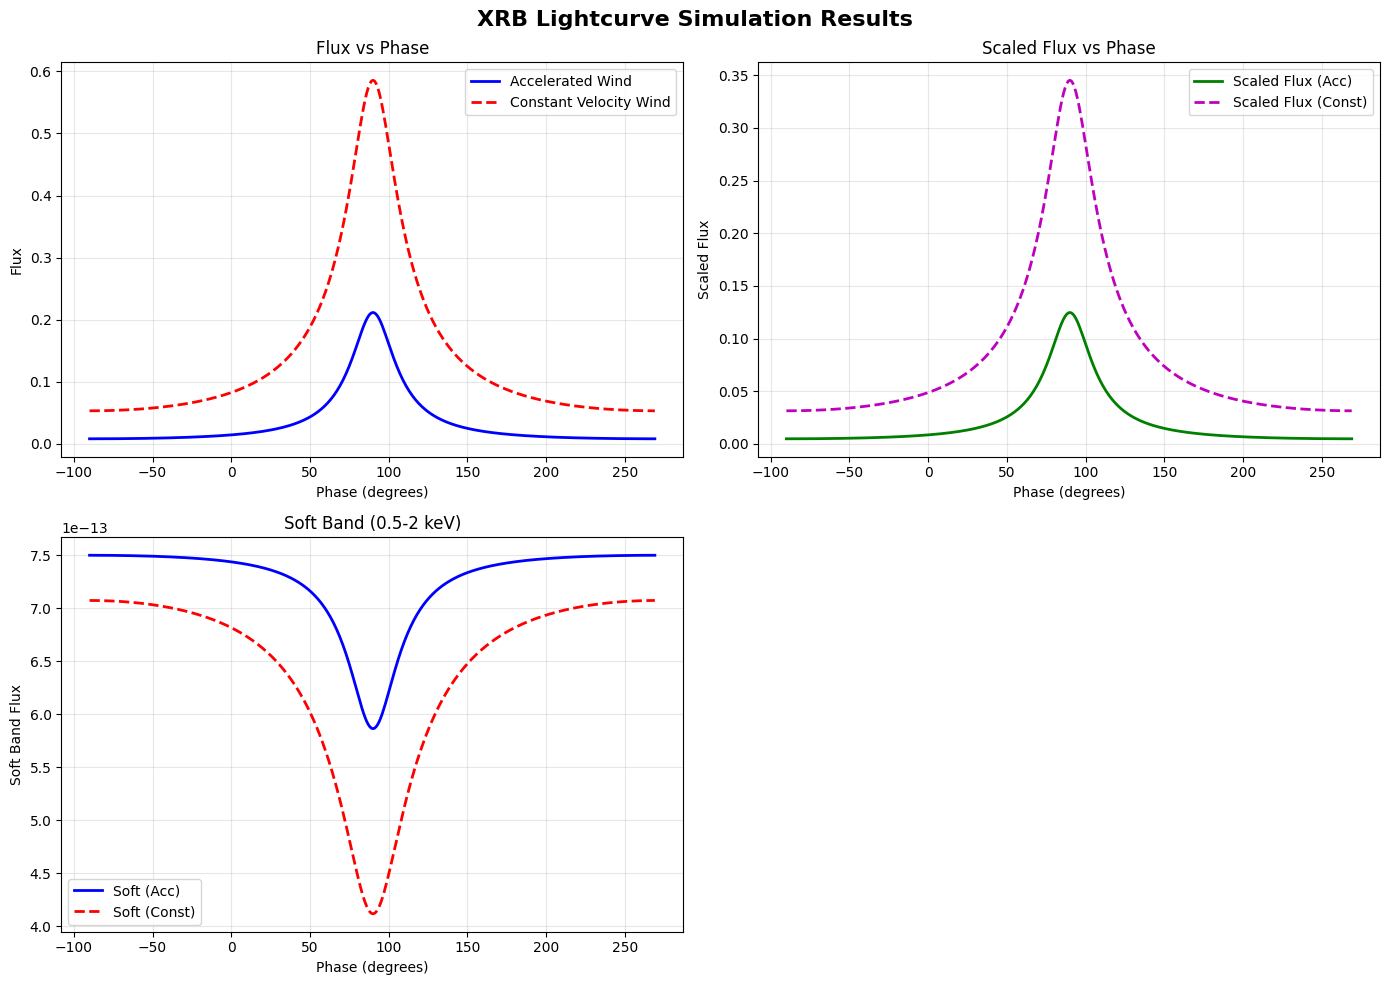

In [17]:
# Plot model Lightcurve
plot_lightcurve("./analyses/sim_flux_interpolate_phabs_soft.csv")

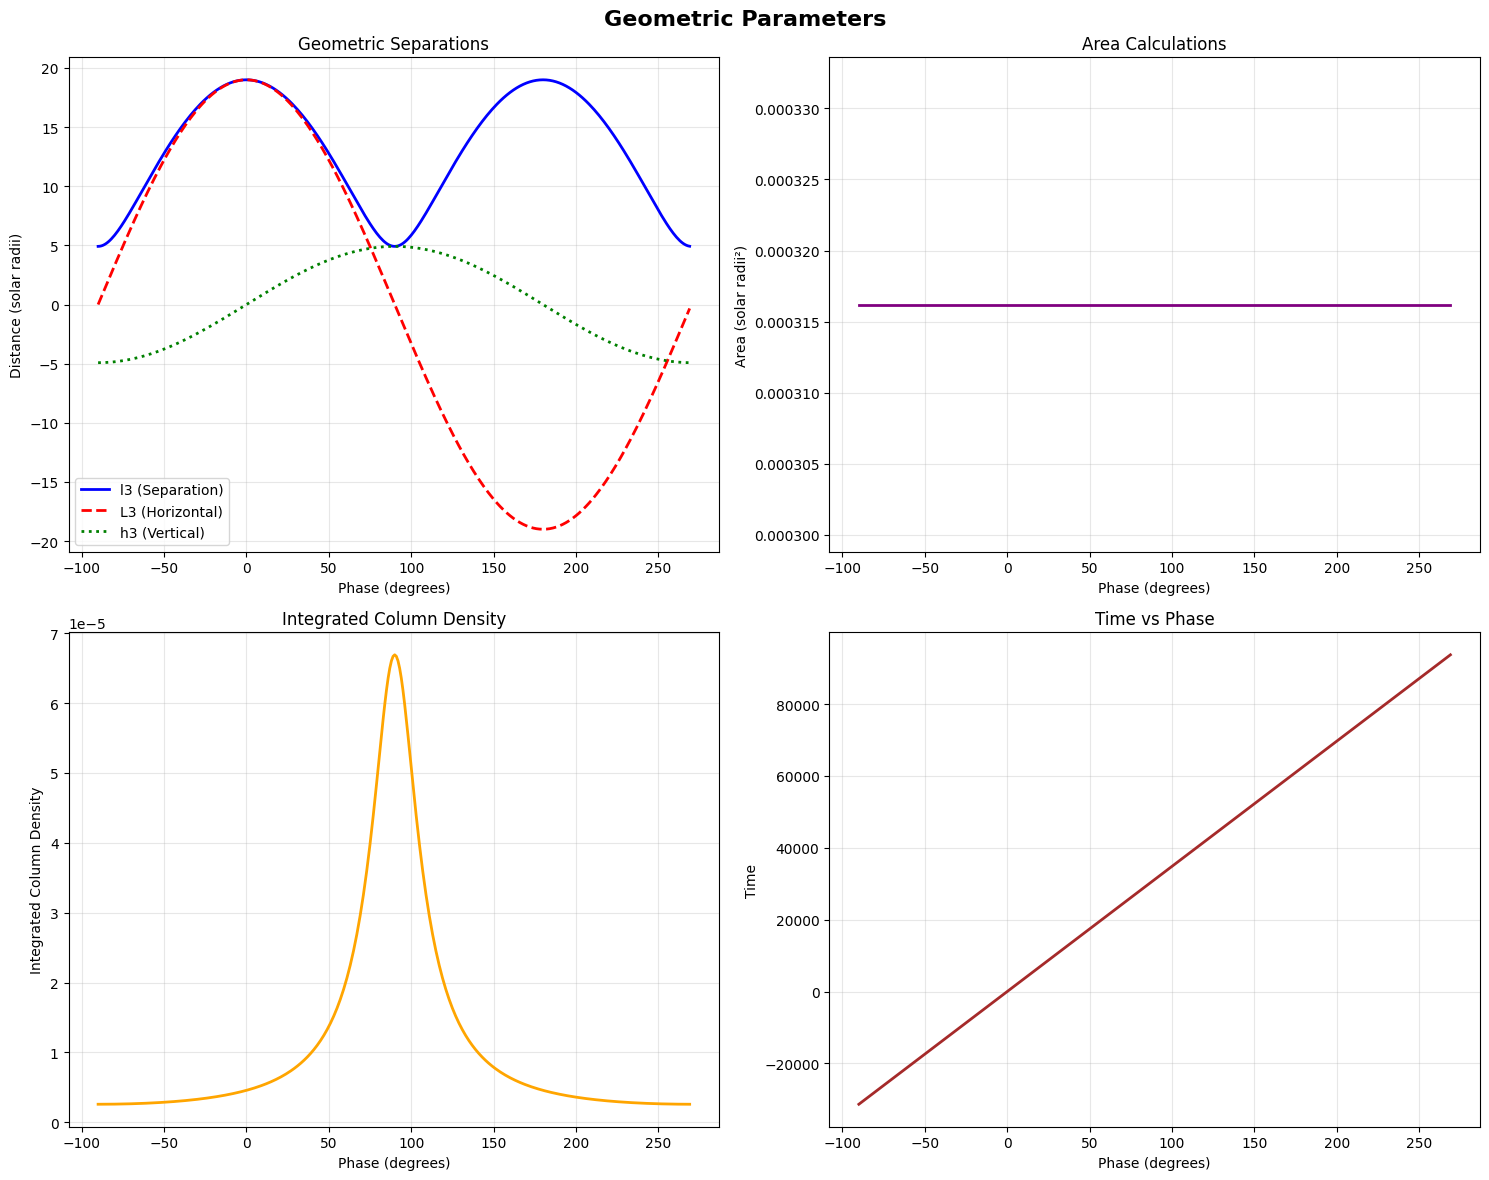

In [18]:
plot_geometric_parameters("./analyses/sim_flux_interpolate_phabs_soft.csv")

## Plot Model LC with Chandra data

Loading 12 observation file(s) from ./data/IC_10_X1_LC/Soft_with_flux


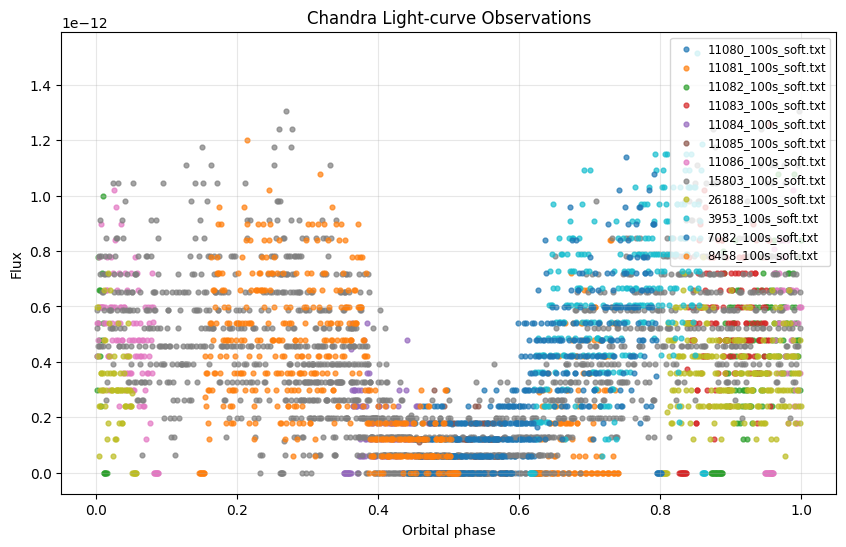

In [13]:
obs_column = "FLUX"
#time_column = "t_raw"
df = load_data("./data/IC_10_X1_LC/Soft_with_flux", obs_column = obs_column)
plot_phase(df, None, obs_column_name = obs_column)

Loading 12 observation file(s) from ./data/IC_10_X1_LC_CIAO/soft
Removed 543 zero/NaN flux data points (3694 remaining)


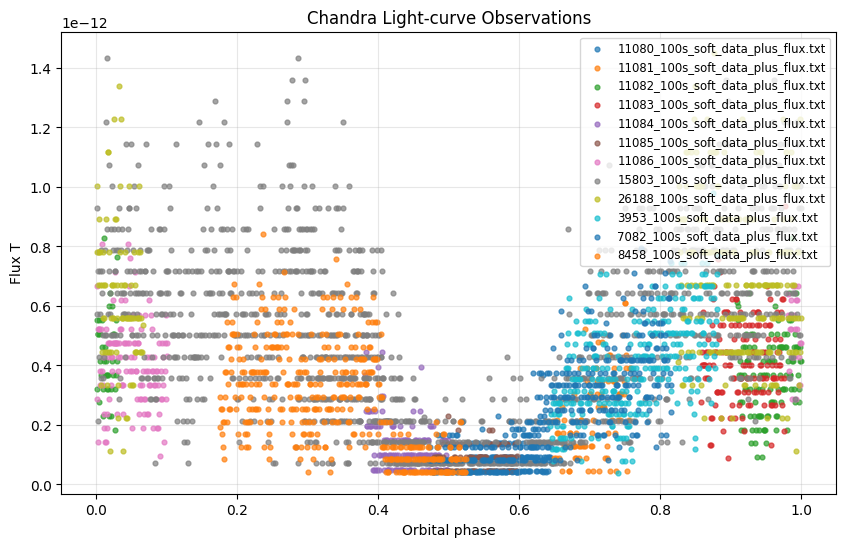

In [14]:
obs_column = "flux_t"
time_column = "t_raw"
df = load_data("./data/IC_10_X1_LC_CIAO/soft", obs_column = obs_column, time_column = time_column)
n_before = len(df)
df = df[(df['rate'] != 0) & (df['rate'].notna())].reset_index(drop=True)
n_removed = n_before - len(df)
if n_removed > 0:
    print(f"Removed {n_removed} zero/NaN flux data points ({len(df)} remaining)")
plot_phase(df, None, obs_column_name = obs_column)


Fitting column: nfl_soft_av
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 20.439

Fitting column: nfl_soft_cv
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 12.131


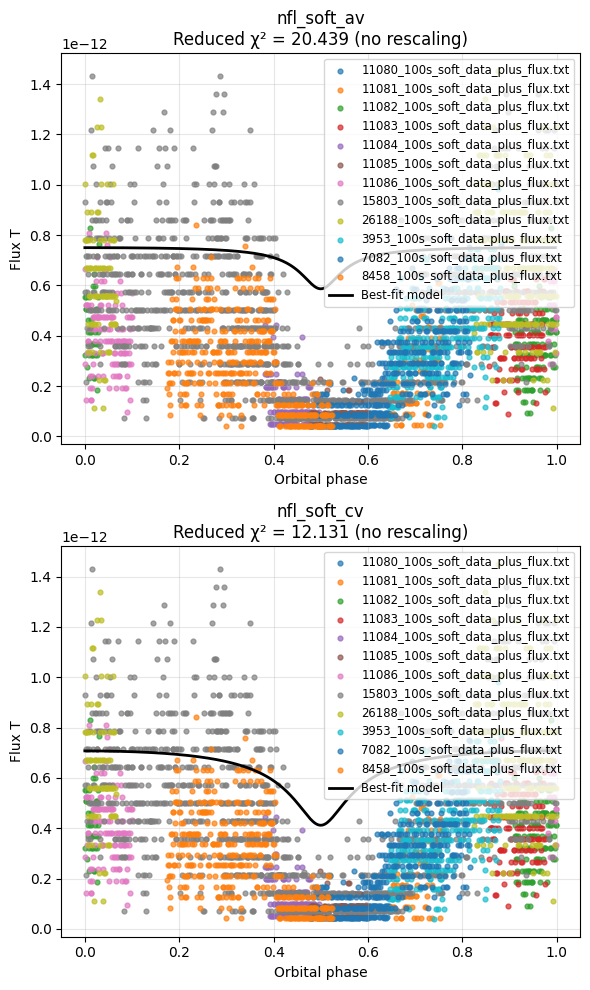

In [19]:
# os.system("python chandra_phase_analysis.py --data-dir ./data/IC_10_X1_LC_CIAO/soft \
# --obs-column flux_t --time-column t_raw --no-phase-bin --sim-file ./analyses/sim_flux_interpolate_phabs_soft.csv")
sim_df = pd.read_csv("./analyses/sim_flux_interpolate_phabs_soft.csv")
sim_columns = detect_flux_columns(sim_df)
fit_results = []
for col in sim_columns:
    print(f"\n{'='*60}")
    print(f"Fitting column: {col}")
    print('='*60)
    try:
        shift, scale, chi2 = fit_simulation(df, sim_df, col, rescale=False)
        fit_results.append((shift, scale, chi2))
    except:
        None
if len(sim_columns) == 1:
    # Single column: use original plot
    shift, scale, chi2 = fit_results[0]
    plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2, 
                rescaled=args.rescale, obs_column_name=obs_column, is_binned=False)
else:
    # Multiple columns: use grid plot
    plot_multi_column_fits(df, None, sim_df, sim_columns, fit_results, 
                            rescaled=False, obs_column_name=obs_column, is_binned=False)

## IC10X1 spectrum: XSpec model

In [1]:
from compute_flux_vs_nH import *
specdir = "data/IC10X1_spec"
instrument = "chandra"
src, bkg, rmf, arf = find_spectrum_files(specdir)
load_data(src, bkg, rmf, arf)


1 spectrum  in use
 
Spectral Data File: X1_spectrum_combined_src.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  6.920e-02 +/- 5.839e-04 (95.8 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: CHANDRA Instrument: ACIS  Channel Type: PI
  Exposure Time: 2.178e+05 sec
 Using fit statistic: chi
 Using Background File                X1_spectrum_combined_bkg.pi
  Background Exposure Time: 2.178e+05 sec
 Using Response (RMF) File            X1_spectrum_combined_src.rmf for Source 1
 Using Auxiliary Response (ARF) File  X1_spectrum_combined_src.arf

Net count rate (cts/s) for Spectrum:1  6.920e-02 +/- 5.839e-04 (95.8 % total)


In [2]:
AllData.ignore("**-0.5, 7.0-**")

    35 channels (1-35) ignored in spectrum #     1
   545 channels (480-1024) ignored in spectrum #     1



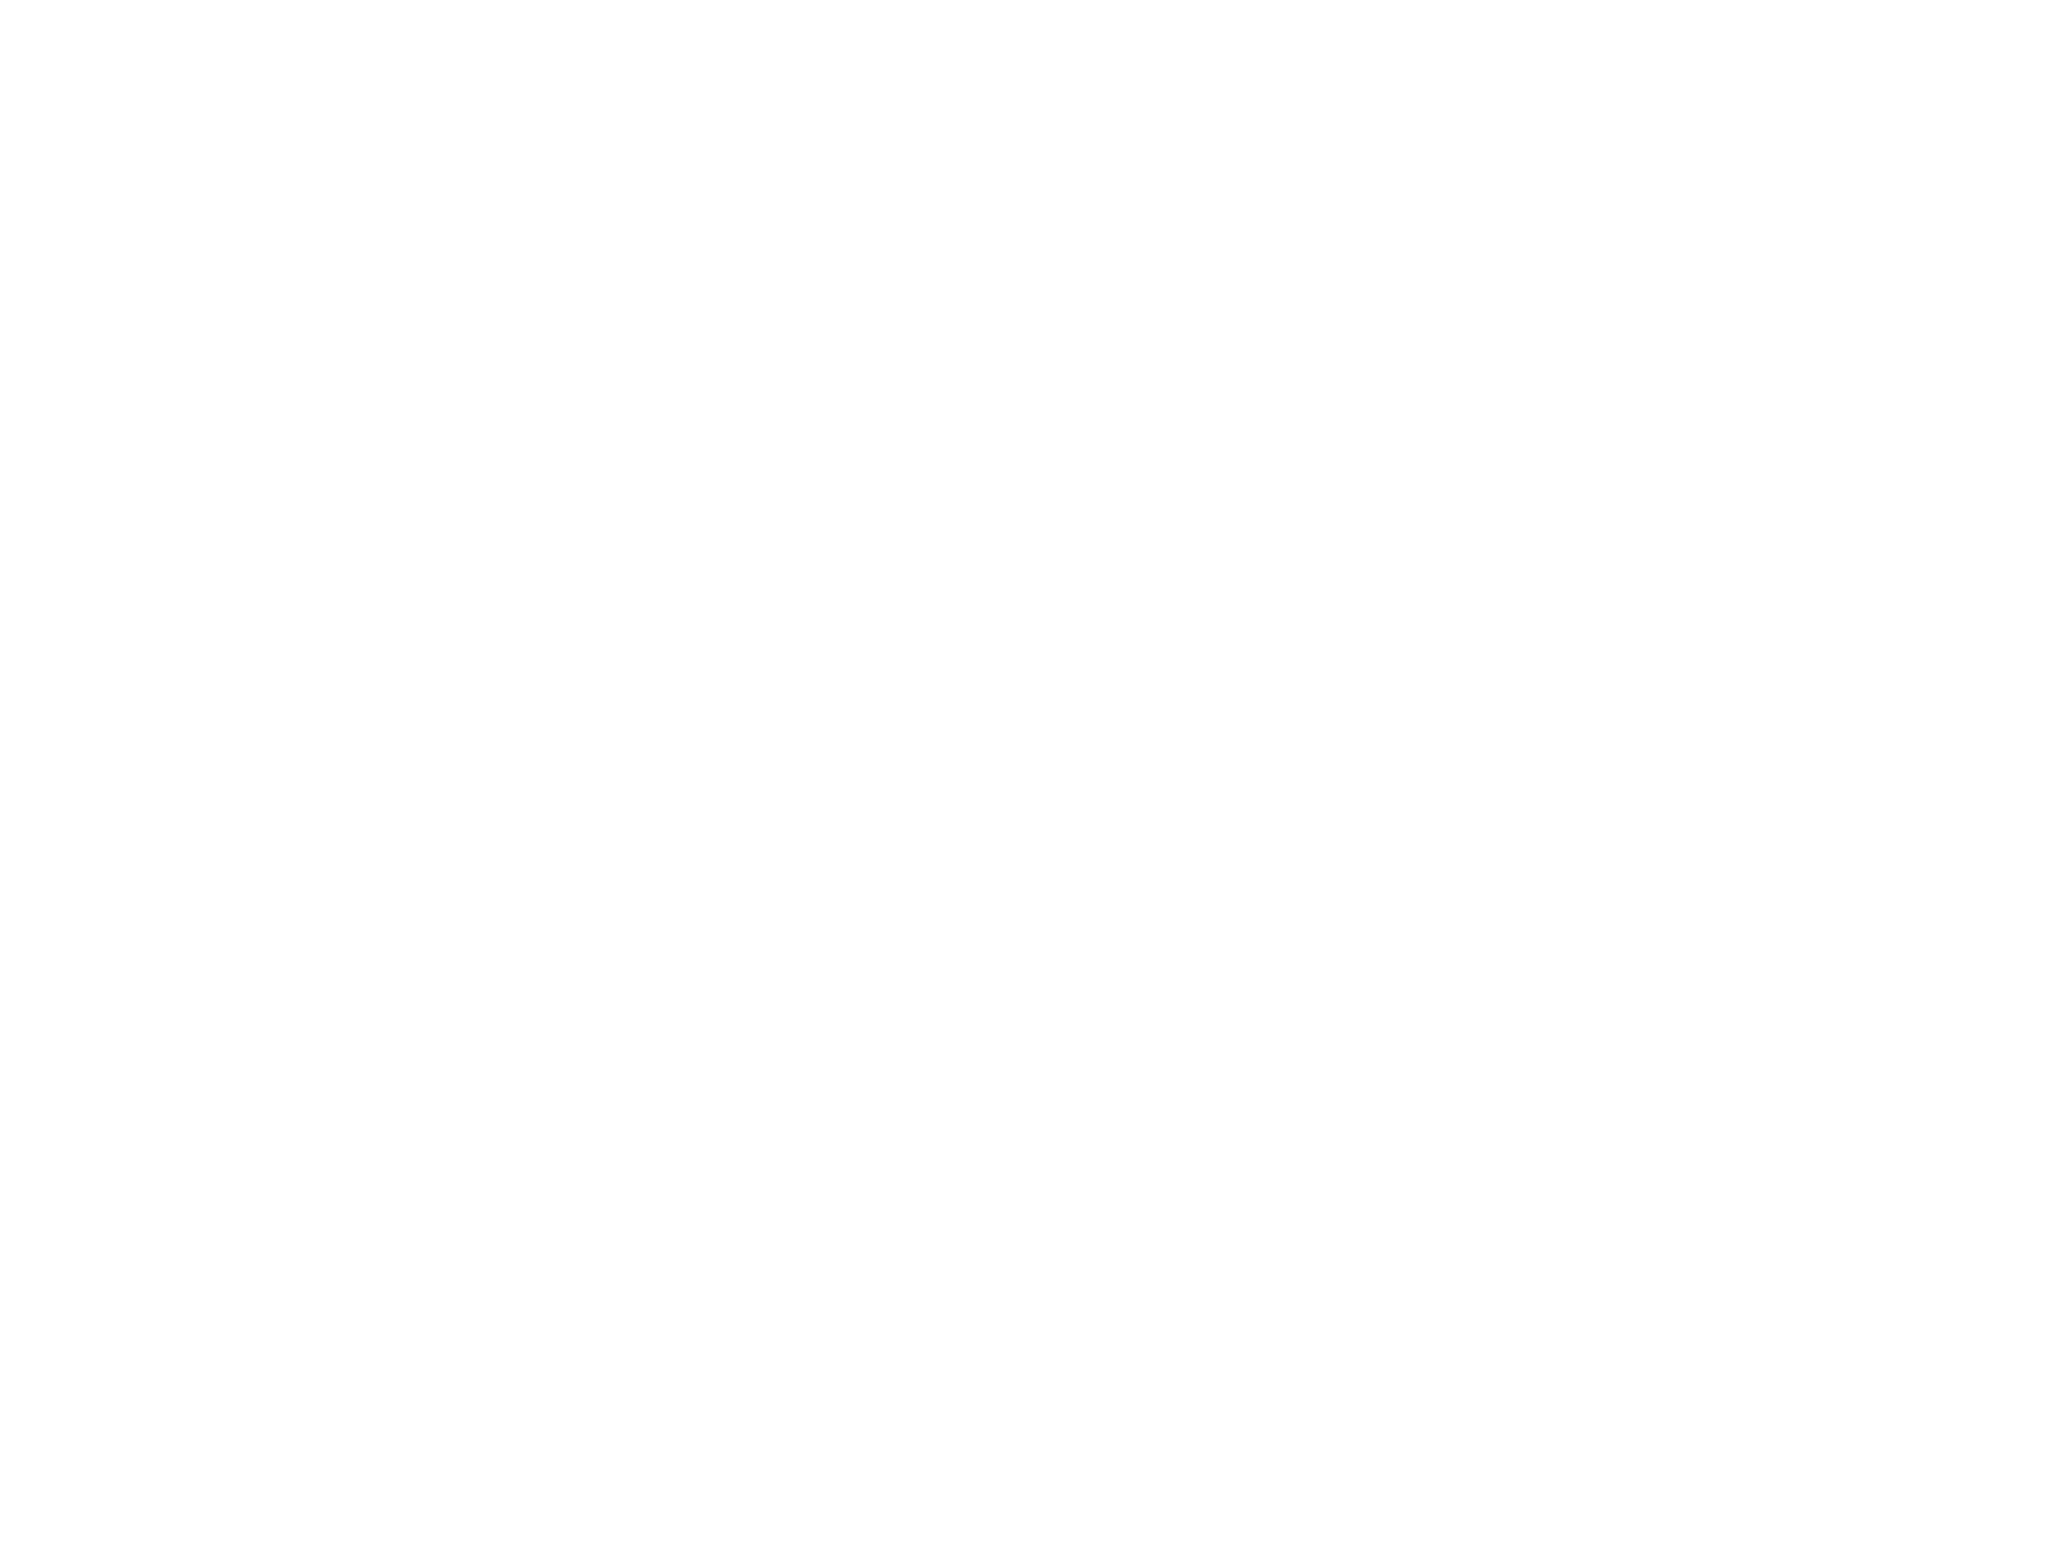

In [3]:
# Plot spectrum data
Plot.device = "/svg"
Plot.xAxis = "KeV"
Plot("data")

In [41]:
# Load an absorber model with powerlaw
m1 = Model("tbfeo*(po+diskbb)")
m1.powerlaw.PhoIndex = 1.92146
m1.powerlaw.norm = 3.37606e-04
m1.TBfeo.nH = 0.5
m1.TBfeo.O = 0.767
m1.diskbb.Tin = 1.8
m1.show()


Model TBfeo<1>(powerlaw<2> + diskbb<3>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBfeo      nH         10^22    1.00000      +/-  0.0          
   2    1   TBfeo      O                   1.00000      frozen
   3    1   TBfeo      Fe                  1.00000      frozen
   4    1   TBfeo      redshift            0.0          frozen
   5    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   6    2   powerlaw   norm                1.00000      +/-  0.0          
   7    3   diskbb     Tin        keV      1.00000      +/-  0.0          
   8    3   diskbb     norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared              4.743039e+11     using 444 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number: 1

Test statistic : Chi-Squared              4.743039e+

In [42]:
# Fit model with data
Fit.nIterations = 100
Fit.perform()
Fit.show()

                                   Parameters
Chi-Squared  |beta|/N    Lvl          1:nH    5:PhoIndex        6:norm         7:Tin        8:norm
1329.64      618955        0      0.408607       6.31111   1.21283e-05       1.78881    0.00704942
956.822      4.2029e+06   -1      0.318225       3.89495   3.41006e-06       1.74225    0.00717562
927.856      1.16218e+06   0      0.319921       2.81917   2.50472e-06       1.74160    0.00717315
924.675      311757        0      0.321115       1.20855   2.07233e-06       1.74094    0.00717091
921.018      287609        0      0.328556       2.90125   2.02539e-06       1.74068    0.00722886
919.495      190313        1      0.328638       2.69072   1.98863e-06       1.74062    0.00722877
918.461      113601        1      0.328714       2.51201   1.96542e-06       1.74056    0.00722869
917.82       61080.2       1      0.328787       2.37557   1.95271e-06       1.74050    0.00722859
917.429      28890         1      0.328856       2.27668   1.94

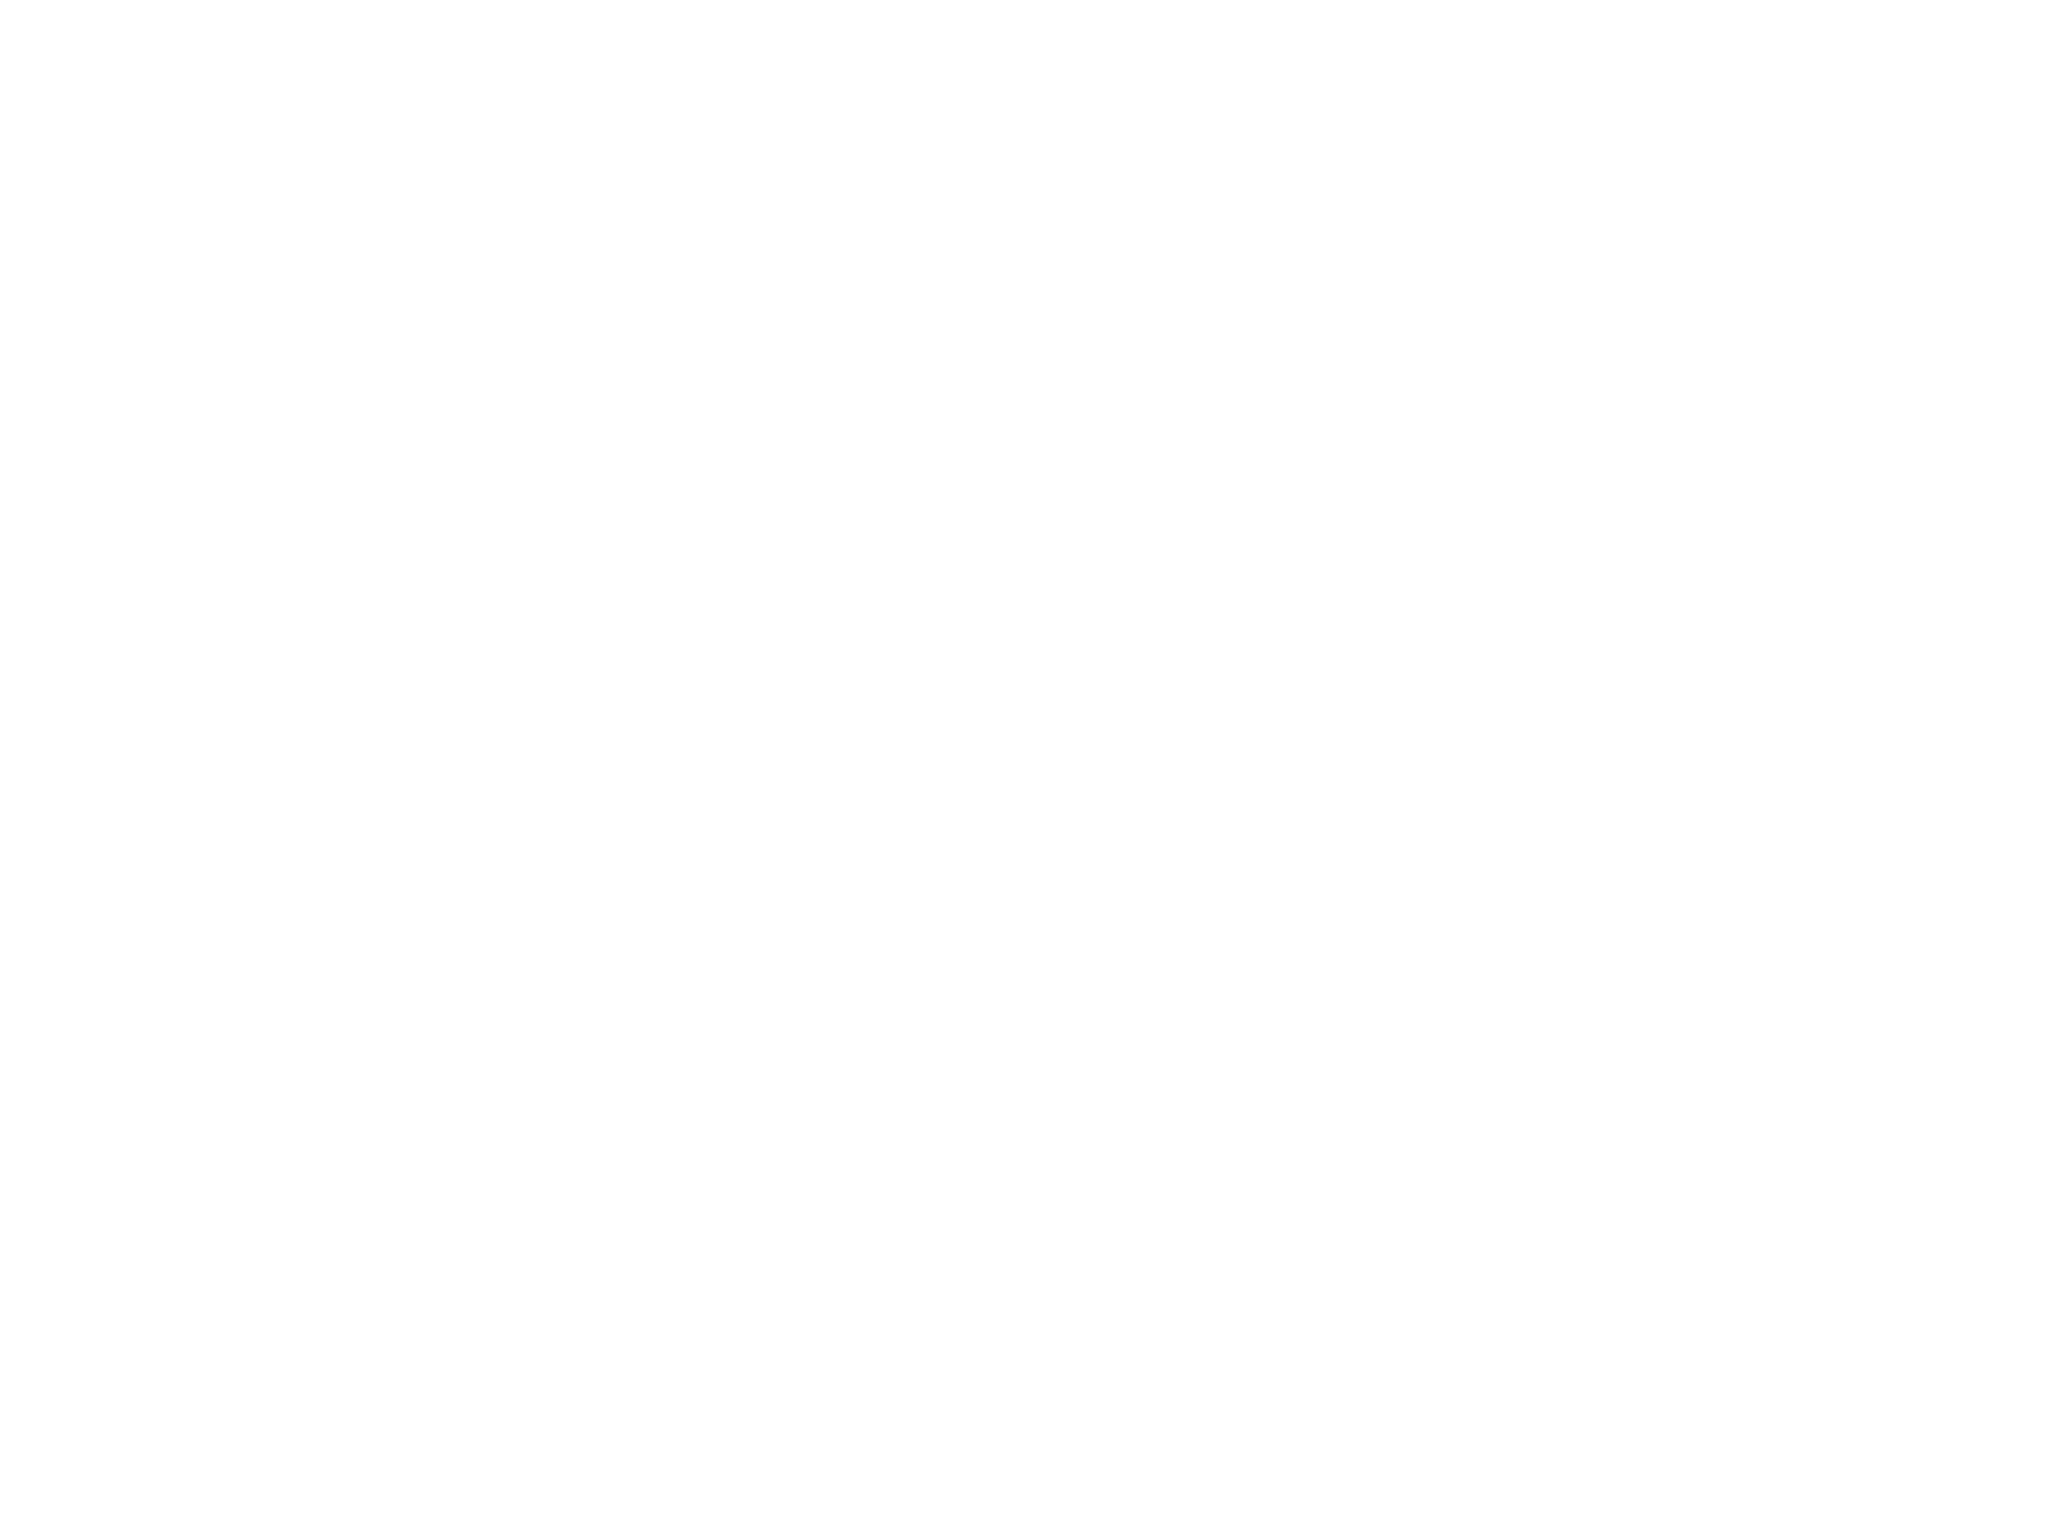

In [43]:
Plot("Model","data","res")